In [1]:
from src.utils.paths import PROJECT_ROOT, DATA_DIR, EXTERNAL_DATA_DIR, IMAGERY_ROOT, RAW_DATA_DIR

In [7]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
IMAGERY_ROOT

'E:\\Datasets\\Imagenes Satelitales\\New York City'

In [2]:
from src import build_dataset

datasets, extents = build_dataset.load_satellite_datasets(year=2014, stretch=False, engine="zarr")

Loading 1 files from /mnt/e/Datasets/Imagenes Satelitales/New York City...


In [7]:
import numpy as np
import geopandas as gpd

def get_test_area_from_file(filename = "Test_NYC_Area.parquet"):
    test = gpd.read_parquet(RAW_DATA_DIR / filename)
    print(test.crs)
    test_polygon = test.dissolve().geometry.iloc[0]
    return test_polygon

def split_train_test_polygon(gdf, test_polygon, buffer=0):
    """
    Splits the GeoDataFrame into 'train' and 'test' based on a test_polygon.
    
    Logic:
    - TEST:  Geometry is strictly INSIDE the test_polygon.
    - TRAIN: Geometry is strictly OUTSIDE the (test_polygon + buffer).
    - DROP:  Geometry overlaps the border or falls within the buffer zone.
    """
    
    # Initialize column with NaNs
    gdf["type"] = np.nan

    # 1. Identify TEST rows
    # "within" checks if the feature is fully contained inside the test polygon
    test_mask = gdf.geometry.within(test_polygon)
    gdf.loc[test_mask, "type"] = "test"

    # 2. Identify TRAIN rows
    # We buffer the test polygon to create the "exclusion zone"
    # "disjoint" checks if the feature has absolutely no overlap with the buffered zone
    exclusion_zone = test_polygon.buffer(buffer)
    train_mask = gdf.geometry.disjoint(exclusion_zone)
    gdf.loc[train_mask, "type"] = "train"

    # 3. Calculate and Print Stats
    test_size = gdf[gdf["type"] == "test"].shape[0]
    train_size = gdf[gdf["type"] == "train"].shape[0]
    invalid_size = gdf[gdf["type"].isna()].shape[0]
    total_size = gdf.shape[0]

    print(
        "",
        f"Size of test dataset: {test_size/total_size*100:.2f}% ({test_size} features)",
        f"Size of train dataset: {train_size/total_size*100:.2f}% ({train_size} features)",
        f"Deleted images due to train/test overlapping: {invalid_size/total_size*100:.2f}% ({invalid_size} features)",
        sep="\n",
    )

    return gdf

gdf = build_dataset.load_income_dataset(variable="avg_hh_inc", trim=False)
test_polygon = get_test_area_from_file()
split_train_test_polygon(gdf, test_polygon, buffer=500)

{"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "BoundCRS", "source_crs": {"type": "ProjectedCRS", "name": "unknown", "base_crs": {"name": "unknown", "datum": {"type": "GeodeticReferenceFrame", "name": "Unknown based on GRS 1980 ellipsoid using towgs84=0,0,0,0,0,0,0", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101, "id": {"authority": "EPSG", "code": 7019}}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Latitude", "abbreviation": "lat", "direction": "north", "unit": "degree"}, {"name": "Longitude", "abbreviation": "lon", "direction": "east", "unit": "degree"}]}}, "conversion": {"name": "unknown", "method": {"name": "Lambert Conic Conformal (2SP)", "id": {"authority": "EPSG", "code": 9802}}, "parameters": [{"name": "Latitude of false origin", "value": 40.1666666666667, "unit": "degree", "id": {"authority": "EPSG", "code": 8821}}, {"name": "Longitude of false origin", "value": -74, "unit": 

/tmp/ipykernel_25278/3844879608.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'test' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  gdf.loc[test_mask, "type"] = "test"



Size of test dataset: 23.94% (107673 features)
Size of train dataset: 73.13% (328875 features)
Deleted images due to train/test overlapping: 2.93% (13179 features)


,capture_da,boroname,index_righ,GEOID,STATE,COUNTY,TRACT,NAME,CNTY_FIPS,avg_hh_inc,geometry,var,type
0,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1067053.173 209139.295, 1067044.762 ...",0.903605,train
1,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066993.434 211949.564, 1067030.554 ...",0.903605,train
2,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066744.615 209584.918, 1066783.937 ...",0.903605,train
3,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066671.441 209426.912, 1066706.044 ...",0.903605,train
4,None,Queens,74995,36081157903,36,081,157903,Census Tract 1579.03,36081,104135,"POLYGON ((1066621.379 208092.188, 1066602.7 20...",0.317018,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
457302,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914278.373 123196.517, 914236.906 12...",1.036937,train
457303,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914230.566 124269.59, 914264.523 124...",1.036937,train
457304,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914203.412 124013.548, 914200.86 123...",1.036937,train
457305,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((913923.046 124090.499, 913924.229 12...",1.036937,train


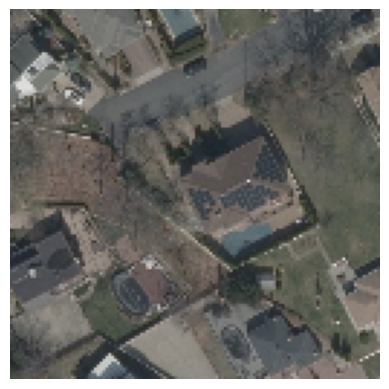

In [59]:
import numpy as np
random_int = np.random.randint(0, high=1)
random_int2 = np.random.randint(0, high=64)

test = np.load(rf"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/results/effnet_v2S_lr0.0001_size128_y2020_stack1-4/examples/effnet_v2S_lr0.0001_size128_y2020_stack1-4_test_example_{random_int}_imgs.npy")
import matplotlib.pyplot as plt

# Plot the numpy array as an image
plt.imshow(test[random_int2, :, :, 4:7])
plt.axis('off')  # Turn off the axis
plt.show()

In [1]:
import pandas as pd

pd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/test_datasets/effnet_v2S_lr0.0001_size128_y2020_stack1-4_test_dataframe.feather")

,GEOID,var,type,geometry,dataset_2020
0,36081041400,-0.519757,test,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2020.zarr
1,36081026400,-0.144085,test,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...,nyc_2020.zarr
2,36081046800,-0.499046,test,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\t\x00\x...,nyc_2020.zarr
3,36081026400,-0.144085,test,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2020.zarr
4,36081044400,-1.310624,test,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2020.zarr
...,...,...,...,...,...
107668,36085018100,0.360341,test,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2020.zarr
107669,36085018703,0.634075,test,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2020.zarr
107670,36085013800,1.030428,test,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2020.zarr
107671,36085013800,1.030428,test,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2020.zarr


In [1]:
%load_ext tensorboard

In [3]:
%tensorboard --logdir "../logs"

Reusing TensorBoard on port 6006 (pid 219632), started 0:00:04 ago. (Use '!kill 219632' to kill it.)

In [ ]:
import geopandas as gpd
gpd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/test_datasets/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_test_dataframe.feather")

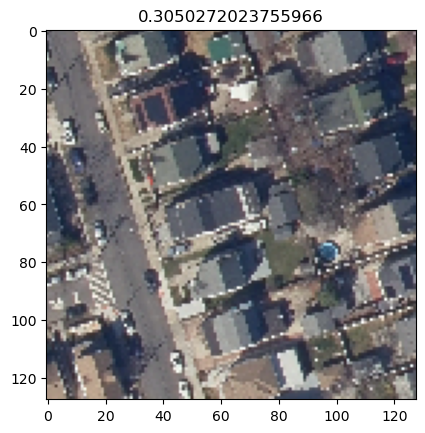

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.load


img = np.load("/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/debug_examples/effnet_v2S_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_example_img.npy")
lbl = np.load("/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/debug_examples/effnet_v2S_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_example_lbl.npy")

plt.imshow(img[..., 4:7])  # first band
plt.title(lbl)
plt.show()



In [7]:
from src import geo_utils
import pandas as pd

df_subset = pd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/train_datasets/effnet_v2S_lr0.0005_size128_y2016_stack1-4_Pooling_train_dataframe.feather")
i = 10
df_subset

,GEOID,var,type,geometry,dataset_2016
0,36061023502,-1.320342,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr
1,36005033700,0.475827,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr
2,36005011502,-2.104887,train,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...",nyc_2016.zarr
3,36047083800,-0.164018,train,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...",nyc_2016.zarr
4,36047041000,-0.642811,train,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...",nyc_2016.zarr
...,...,...,...,...,...
744,36085015601,1.132708,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...,nyc_2016.zarr
745,36081120701,0.316707,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr
746,36085012806,-1.258799,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr
747,36085029105,1.402892,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr


Loading 1 files from /home/abbatenicolas/data...


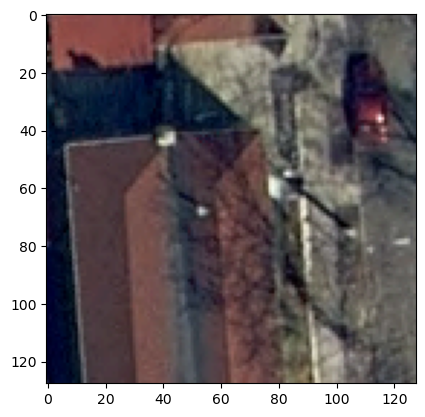

In [71]:
from src import geo_utils, build_dataset
import geopandas as gpd
import pandas as pd
import numpy as np
primary_dataset = build_dataset.load_satellite_datasets(year=2016, stretch=False, engine="zarr")[0]
df_subset = gpd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/train_datasets/effnet_v2S_lr0.0005_size128_y2016_stack1-4_Pooling_train_dataframe.feather")
i = np.random.randint(0, len(df_subset))
batch_year = 2016
nbands = 4
stacked_images = [1, 4]
image_size = 128
resizing_size = 128
total_bands = len(stacked_images) * nbands
target_shape = (resizing_size, resizing_size, total_bands)

polygon = df_subset.iloc[i]["geometry"]
value = df_subset.iloc[i]["var"]

# Logic to get dataset
dataset_name = df_subset.iloc[i][f"dataset_{batch_year}"]
link_dataset = primary_dataset[dataset_name]

# RANDOM CROP HAPPENS HERE
image, _ = geo_utils.stacked_image_from_census_tract(
    dataset=link_dataset,
    polygon=polygon,
    img_size=image_size,
    n_bands=nbands,
    stacked_images=stacked_images,
)
image, value
image = np.transpose(image, (1, 2, 0))

plt.imshow(image[..., 0:3])  # first band


In [86]:
def get_mini_batch_data(batch_indices, df_subset):
    indices = batch_indices
    batch_imgs = []
    batch_lbls = []
    
    # Randomly pick a year for this batch to optimize Zarr access
    batch_year = 2016
    
    total_bands = nbands * len(stacked_images)
    target_shape = (total_bands, image_size, image_size)
    
    for i in indices:
        # ... (Standard extraction logic) ...
        try:
            polygon = df_subset.iloc[i]["geometry"]
            value = df_subset.iloc[i]["var"]
            
            # Logic to get dataset
            dataset_name = df_subset.iloc[i][f"dataset_{batch_year}"]
            if not pd.isna(dataset_name):
                link_dataset = primary_dataset[dataset_name]
            else:
                link_dataset = None # (Fallback logic omitted for brevity, add back if needed)

            image = np.zeros(shape=(nbands, 0, 0))
            if link_dataset is not None:
                # RANDOM CROP HAPPENS HERE
                image, _ = geo_utils.stacked_image_from_census_tract(
                    dataset=link_dataset,
                    polygon=polygon,
                    img_size=image_size,
                    n_bands=nbands,
                    stacked_images=stacked_images,
                )
            
            if image.shape != target_shape:
                    image = np.zeros(shape=(resizing_size, resizing_size, total_bands))
                    return None  
            else:
                    image = geo_utils.process_image(image, resizing_size)
                    # NO AUGMENTATION HERE (We cache the clean image)

            batch_imgs.append(image)
            batch_lbls.append(value)

        except Exception as e:
            print(e)
            # Fail-safe
            batch_imgs.append(np.zeros((resizing_size, resizing_size, total_bands)))
            batch_lbls.append(0.0)


    return np.stack(batch_imgs).astype(np.uint8), np.stack(batch_lbls).astype(np.float32)

get_mini_batch_data(np.random.randint(0, len(df_subset), size=4), df_subset)

(array([[[[152, 156, 148, ..., 172, 168, 168],
          [152, 156, 148, ..., 188, 184, 176],
          [148, 156, 148, ..., 180, 180, 168],
          ...,
          [  4,  20,  28, ..., 196, 188, 188],
          [  4,  24,  36, ..., 196, 188, 184],
          [ 12,  28,  36, ..., 192, 184, 184]],
 
         [[152, 156, 148, ..., 112, 108, 104],
          [148, 156, 148, ..., 140, 136, 132],
          [148, 156, 144, ...,  92, 100,  88],
          ...,
          [  0,  16,  28, ..., 196, 188, 188],
          [  4,  20,  32, ..., 196, 188, 188],
          [  8,  24,  36, ..., 200, 188, 192]],
 
         [[152, 156, 148, ...,  56,  64,  68],
          [152, 160, 148, ...,  32,  40,  44],
          [152, 160, 148, ...,  60,  72,  64],
          ...,
          [  4,  16,  28, ..., 200, 188, 188],
          [  0,  16,  28, ..., 200, 192, 188],
          [ 12,  24,  36, ..., 212, 200, 200]],
 
         ...,
 
         [[112, 108,  92, ..., 112, 116,  96],
          [116, 112, 100, ..., 116, 1

In [8]:
link_dataset

<xarray.Dataset> Size: 416GB
Dimensions:      (band: 4, y: 320000, x: 325000)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
    spatial_ref  int64 8B ...
  * x            (x) float64 3MB 9.075e+05 9.075e+05 ... 1.07e+06 1.07e+06
  * y            (y) float64 3MB 2.775e+05 2.775e+05 ... 1.175e+05 1.175e+05
Data variables:
    value        (band, y, x) uint8 416GB ...

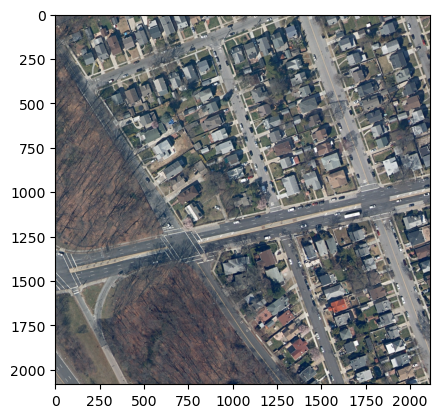

In [26]:
import matplotlib.pyplot as plt

bounds = polygon.buffer(500).bounds
img = link_dataset.sel(y=slice(bounds[3], bounds[1]), x=slice(bounds[0], bounds[2])).value.to_numpy()
img = np.transpose(img, (1, 2, 0))

plt.imshow(img[..., :3])  # first band
plt.show()


In [ ]:
polygon

<Axes: >

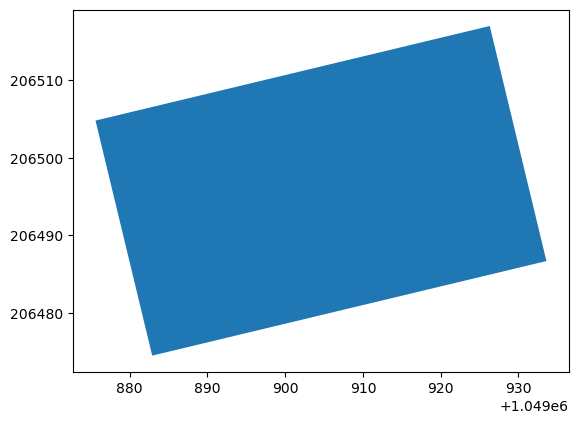

In [24]:
gpd.GeoDataFrame(geometry=[polygon]).set_crs("EPSG:6539").plot()


In [20]:
img.shape

(4, 2083, 2114)

In [28]:
gpd.GeoDataFrame(geometry=[polygon]).set_crs("EPSG:6539").explore()

In [16]:
image

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [14]:
polygon

b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\xedY\xf1\xe7\x1a\x050Ar\x19f>T4\tA\xc7\x1f\\\x9e\x13\x050AC^\xc7\x00F5\tA0\xa4\x8fMF\x050A\x80\xce\x8bH\xa75\tA\xc7\xc5(\x97M\x050A\x7fo2\x86\xb54\tA\xedY\xf1\xe7\x1a\x050Ar\x19f>T4\tA'

In [12]:
primary_dataset[0]

{'nyc_2016.zarr': <xarray.Dataset> Size: 416GB
 Dimensions:      (band: 4, y: 320000, x: 325000)
 Coordinates:
   * band         (band) int64 32B 1 2 3 4
     spatial_ref  int64 8B ...
   * x            (x) float64 3MB 9.075e+05 9.075e+05 ... 1.07e+06 1.07e+06
   * y            (y) float64 3MB 2.775e+05 2.775e+05 ... 1.175e+05 1.175e+05
 Data variables:
     value        (band, y, x) uint8 416GB ...}